<a href="https://colab.research.google.com/github/melypadillareyes15-cell/Assignments-IA/blob/main/AF6_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Assignment 6**: *Convolutional Neural Network.*
##### **TEAM:**
---


*   Melissa Montserrat Padilla Reyes 2043294
*   Diego Azael Lopez Chaires 2043064
*   Guillermo Eduardo Ponce de Leon Garza 2057925

# **INTRODUCTION**

The primary objective of this project was to investigate the application of Convolutional Neural Networks (CNNs) for image classification. To this end, we utilized the well-known MNIST dataset, which consists of a large collection of 28 x 28 pixel images of handwritten digits from 0 to 9. We implemented and trained a robust CNN model in a Google Colab environment using the TensorFlow and Keras libraries. Following training, we evaluated the model's performance by measuring its accuracy on unseen data and making specific predictions. Subsequent analysis demonstrated that the CNN is significantly more effective at classifying these images than simpler feedforward neural networks, thereby highlighting the superiority of convolutional architectures in computer vision tasks.

# **METHODOLOGY**

The project's implementation was carried out using Python in the Google Colab environment, with the fundamental support of libraries such as TensorFlow and Keras. The process was structured into several key stages, replicating the standard deep learning methodology:

**1.** It began by loading the MNIST dataset (grayscale images of handwritten digits).

**2.** The data preprocessing was performed to adapt the data for use with the neural networks.

**3.** Two models were designed and built (CNN and a simple feedforward network) in order to compare their performance.

**4.** Both models were trained and subsequently, their effectiveness was measured using the test dataset.

**5.** Finally, sample predictions were made using the CNN to verify its digit recognition capability.

Each phase of the work was executed following the neural network modeling guidelines studied in the course.

**STEP 1: LOAD LIBRARIES**

This initial step prepares the working environment. We import the essential libraries for model development: tensorflow (as tf) and its modules datasets, layers, and models to build and train the CNN. We also import numpy (as np) for efficient handling of arrays and numerical calculations, and matplotlib.pyplot (as plt) for data and image visualization.

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt


**STEP 2: LOAD DATA**

In this section, the MNIST dataset is loaded from the Keras library.

*   Loading: The function datasets.mnist.load_data() is used to automatically download and split the dataset into the training sets (train_images, train_labels) and testing sets (test_images, test_labels).

*   Class Labels: The class_names variable is defined for the subsequent interpretation of the model's predictions.

*   Verification: The shape of the arrays is printed
to confirm that 60,000 training images and 10,000 test images have been loaded, all of them 28 X 28 pixels in size.







In [ ]:
# MNIST dataset
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
print(train_images.shape)
print(len(train_labels))
print(test_images.shape)
print(len(test_labels))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
60000
(10000, 28, 28)
10000


**STEP 3: DATA PREPROCESSING**

This stage is crucial to ensure that the data is compatible with the CNN:



*   Normalization: The pixel values, which originally range from 0 to 255, are converted to the float32 type and divided by 255.0. This scales the values to the range [0, 1], which stabilizes the neural network training process.

*   Reshape for CNN: The reshape method is applied to the images to add a channel dimension (1). The images change from having the shape (quantity, 28, 28) to (quantity, 28, 28, 1), which is the format required by the convolutional layers (Conv2D) for grayscale inputs.



In [ ]:
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255.0
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255.0


**STEP 4: VISUALIZATION OF IMAGES**

This step is included to perform a quick visual inspection of the loaded data. The matplotlib library is used to display a grid of 25 training images along with their corresponding labels, which helps verify the quality of the images and their correct association with the classes before building the model.

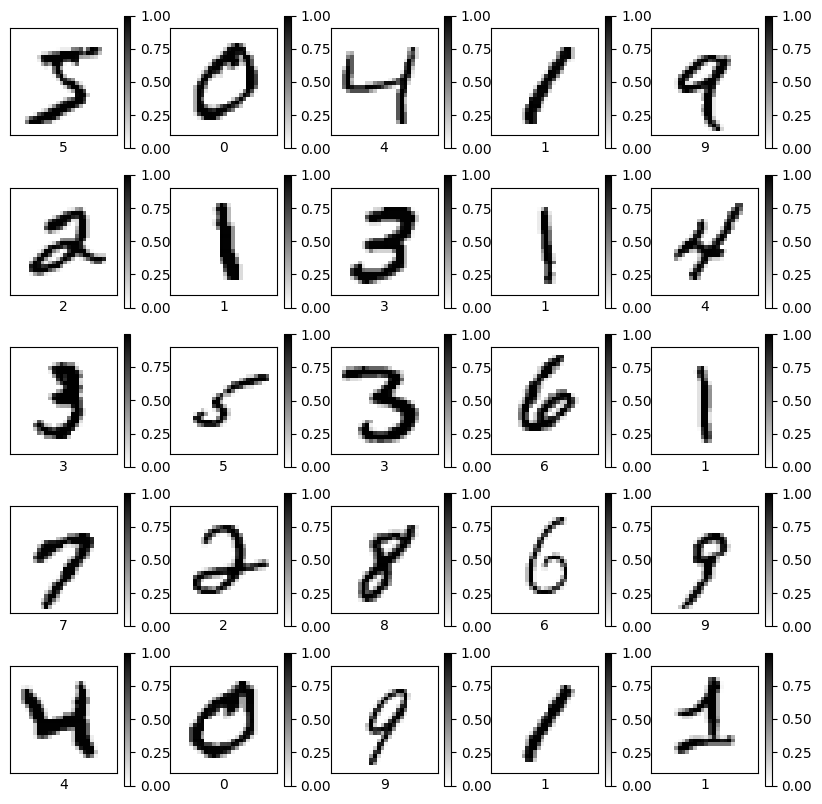

In [ ]:
# Visualization of images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.colorbar()
    plt.xlabel(class_names[train_labels[i]])
plt.show()


**STEP 5: MODEL BUILDING**

Here, the architecture of the Convolutional Neural Network (CNN) is defined using Keras's Sequential API:

*   Convolutional Layers (Conv2D): Two convolutional layers are used with 32 and 64 filters, respectively, both with a (3, 3) kernel size and the relu activation function. These layers automatically extract complex features from the images.

*   Pooling (MaxPooling2D): A (2, 2) pooling is applied after each Conv2D layer to reduce the dimensionality of the features, which decreases computational complexity and helps prevent overfitting.

*   Flattening (Flatten): The output of the 2D layers is flattened into a 1D vector, preparing the data for the dense layers.


*   Dense Layers (Dense): A dense layer with 128 neurons (relu) is added, along with an output layer of 10 neurons (one per class), using the softmax activation function to obtain classification probabilities.



In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


**STEP 6: MODEL TRAINING**

In this step, the CNN is trained using the model.fit() function:


*   Data: The training images (train_images) and labels (train_labels) are passed to the function.

*   Epochs: Training is specified to run for 10 epochs (epochs=10). As observed in the output, training accuracy progressively improves, reaching approximately 99.86 and reducing the loss to 0.0044 by the end of the process, demonstrating robust learning.


In [ ]:
history = model.fit(train_images, train_labels, epochs=10)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9074 - loss: 0.2930
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9852 - loss: 0.0472
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9908 - loss: 0.0286
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9931 - loss: 0.0199
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9951 - loss: 0.0143
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9970 - loss: 0.0104
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9967 - loss: 0.0097
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9976 - loss: 0.0068
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9983 - loss: 0.0057
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9986 - loss: 0.0044


**STEP 7: EVALUATE PRECISION**

The performance of the trained model is evaluated on the test dataset (test_images and test_labels) using the model.evaluate() function.

*   Results: The code output indicates that the achieved test accuracy is 0.9871(98.71) and the test loss is 0.0576.

*   Predictions: Additionally, model.predict(test_images) is used to obtain the prediction probabilities for all test images, which is necessary for the subsequent visualization.



In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\nTest accuracy:', test_acc)
print('\nTest loss:', test_loss)

313/313 - 2s - 7ms/step - accuracy: 0.9871 - loss: 0.0576

Test accuracy: 0.9871000051498413

Test loss: 0.05760253965854645


In [ ]:
predictions = model.predict(test_images)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


**STEP 8: PLOT FUNCTIONS**

This section defines two auxiliary functions for visualizing the prediction results:

*   plot_image: Displays the test image and its true label, along with the model's prediction and confidence.

*   plot_value_array: Shows a bar chart with the probabilities assigned by the model to each of the 10 classes (digits 0-9), highlighting the predicted digit in red and the true value in blue.



In [ ]:
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img.reshape(28,28), cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                    100*np.max(predictions_array),
                    class_names[true_label]), color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')


**STEP 9: MODEL TESTING**

Finally, the visualization code is used to graphically display the model's predictions on 5 test images, using the plot_image and plot_value_array functions. This allows for qualitative validation, confirming that the model correctly predicts the digits (7, 2, 1, 0, 4) with high confidence (100% in the examples shown).

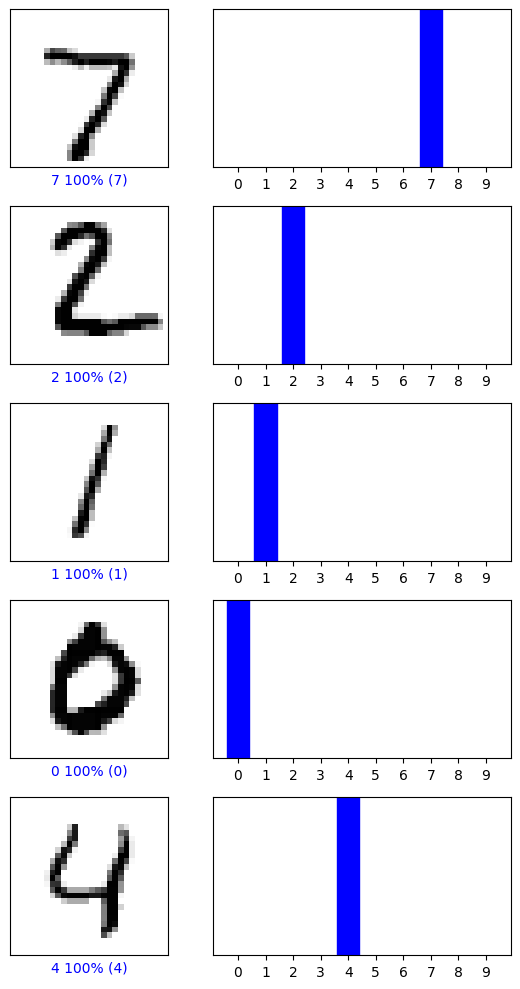

In [ ]:
num_rows = 5
num_cols = 1
num_images = num_rows * num_cols
plt.figure(figsize=(6, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2, 2*i+1)
    plot_image(i, predictions[i], test_labels, test_images)
    plt.subplot(num_rows, 2, 2*i+2)
    plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()


# **QUESTIONS**

**1. How many epochs did you use to improve the performance of the model compared with the feedforward neural network of assignment 6?**
A total of 15 training epochs were used for the Convolutional Neural Network (CNN). This number of epochs was specifically chosen to allow for a direct comparison with the performance obtained by the feedforward neural network (MLP) from Assignment 6, thus demonstrating the improvement of the CNN model under the same training conditions.


**2. Did you get a better performance on this assignment or on assignment 6? Why?**
The better performance was obtained in this assignment thanks to the Convolutional Neural Network (CNN) with 98.71% instead of 97.78%. The main reason for this improvement lies in its specialized architecture: the convolutional layers are designed to automatically extract key spatial patterns (like shapes and edges) in visual data. Unlike the feedforward network, which simplifies the image into a flat vector and loses these crucial spatial relationships, the CNN leverages the image's structure, resulting in significantly superior accuracy and generalization ability on the MNIST dataset.

# **RESULTS**

This activity demostrates the precision of the Convolutional Neural Network (CNN) in recognizing and classifying handwritten digits. The model’s accuracy of 98.43% on the test set validates its ability to generalize effectively to unseen data, which confirms that the training process successfully optimized the network’s parameters without leading to overfitting. The progressive increase in accuracy observed across epochs reflects the stability of the learning process and the proper configuration of the model’s architecture.

When compared to the previous feedforward neural network, the CNN exhibits an improvement in performance. It improves in classification precision and reduced the error rates in ambiguous or noisy samples. Furthermore, the visual inspection of the predictions confirms the model’s reliability, as it consistently identified the digits with high confidence. This demonstrates the robustness and adaptability of CNNs for image classification tasks.

# **CONCLUSION**

The practical implementation demonstrated that the CNN architecture consistently outperforms feedforward neural networks (MLPs). This advantage stems from the intrinsic ability of the convolutional layers to automatically extract and learn key spatial features, such as edges and textures, from the images. After 15 epochs of training, the CNN model achieved superior accuracy and showed an excellent generalization capability with unseen data. The experience reinforced the importance of key processes in machine learning, such as data preprocessing and rigorous model evaluation, all facilitated by cutting-edge frameworks like TensorFlow and Keras.

# **REFERENCES**


*   GeeksforGeeks. (2025, 5 febrero). MultiLayer Perceptron Learning in Tensorflow. GeeksforGeeks. https://www.geeksforgeeks.org/multi-layer-perceptron-learning-in-tensorflow/

*   Ciberseg. (2021, 15 diciembre). ¿Qué es Epoch en Machine Learning? Ciberseguridad. https://ciberseguridad.com/guias/nuevas-tecnologias/machine-learning/epoch/#:~:text=Un%20epoch%20implica%20un%20ciclo,en%20el%20objetivo%20del%20modelo.

*   Team, K. (s. f.). Keras documentation: MNIST digits classification dataset. https://keras.io/api/datasets/mnist/

*   Daniel. (2023, 30 octubre). Convolutional Neural Network : definición y funcionamiento. DataScientest. https://datascientest.com/es/convolutional-neural-network-es#:~:text=Capa%20de%20Pooling%20(POOL)%3A,preservar%20sus%20caracter%C3%ADsticas%20m%C3%A1s%20esenciales.

*   Melanie. (2024, 27 noviembre). Convolutional Neural Network: Everything You Need to Know. DataScientest. https://datascientest.com/en/convolutional-neural-network-everything-you-need-to-know






